In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [77]:
tissue_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\tissue\tissue_data.xlsx"
tissue_clinical_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\tissue\Clinical Data MACE Amsterdam VA.xlsx"

In [78]:
plasma_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\plasma_data.xlsx"
plasma_labels_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\Proteomics sample labels.csv"
plasma_clinical_dir = r"C:\Users\P095551\OneDrive - Amsterdam UMC\Documenten\Venkat\20241126 Sample ordering and info.xlsx"

In [79]:
tissue_data = pd.read_excel(tissue_dir)
tissue_data.head()

,Unnamed: 0,Protein.Group,Protein.Names,Genes,S001,S002,S003,S004,S007,S011,...,S079,S080,S081,S087,S091,S093,S095,Log2 intensity OPL3026_HeLa50ng_07,S006,S084
0,0,Q16585,SGCB_HUMAN,SGCB,9.065723,8.804035,10.121942,8.103925,7.547642,8.372846,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,P51608-2,MECP2_HUMAN,MECP2,9.233215,8.649819,10.810051,9.461354,8.213499,9.181561,...,6.590036,NaN,7.613278,5.974929,NaN,6.578975,NaN,8.069332,6.773532,6.396201
2,2,Q9H3H3,CK068_HUMAN,C11orf68,9.866450,9.624528,8.357053,9.350256,8.462160,9.632663,...,8.897010,NaN,NaN,7.205819,NaN,7.817692,NaN,9.130469,6.774161,7.462926
3,3,Q6ZT12;Q6ZT12-4,UBR3_HUMAN,UBR3,7.386442,7.298594,7.382471,7.472147,NaN,7.684338,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.340680,NaN,NaN
4,4,Q96P70,IPO9_HUMAN,IPO9,9.011502,9.441655,8.578271,9.246102,8.908170,9.363126,...,8.814127,6.376397,6.931440,7.439738,8.585849,8.410148,6.14147,10.378998,6.955465,8.932941


### Match tissue and plasma samples

In [80]:
plasma_data = pd.read_excel(plasma_dir)
matched_samples = [sample for sample in plasma_data.columns[1:] if sample in tissue_data.columns[1:]]
print(matched_samples)
print(len(matched_samples))

['Genes', 'S001', 'S002', 'S003', 'S004', 'S005', 'S060', 'S006', 'S007', 'S008', 'S009', 'S062', 'S010', 'S011', 'S021', 'S012', 'S013', 'S063', 'S014', 'S015', 'S023', 'S016', 'S017', 'S064', 'S018', 'S019', 'S026', 'S020', 'S022', 'S024', 'S025', 'S030', 'S053', 'S032', 'S033', 'S067', 'S034', 'S036', 'S068', 'S038', 'S039', 'S041', 'S069', 'S043', 'S091', 'S045', 'S070', 'S046', 'S047', 'S092', 'S048', 'S049', 'S071', 'S050', 'S093', 'S054', 'S055', 'S057', 'S094', 'S073', 'S074', 'S080', 'S081', 'S096', 'S075', 'S085', 'S086', 'S088', 'S089', 'S072', 'S082', 'S035', 'S078', 'S077', 'S095', 'S029', 'S037', 'S079', 'S061', 'S066', 'S031', 'S052', 'S076', 'S083', 'S087', 'S090']
86


In [81]:
print(plasma_data.shape)
tissue_data.shape

(1896, 87)


(9726, 108)

In [84]:
tissue_data = tissue_data[matched_samples]
tissue_data.shape

(9726, 86)

In [82]:
print(tissue_data.head(3))
assert tissue_data['Genes'].duplicated().sum() == 0, "Duplicate genes found!"

   Unnamed: 0 Protein.Group Protein.Names     Genes      S001      S002  \
0           0        Q16585    SGCB_HUMAN      SGCB  9.065723  8.804035   
1           1      P51608-2   MECP2_HUMAN     MECP2  9.233215  8.649819   
2           2        Q9H3H3   CK068_HUMAN  C11orf68  9.866450  9.624528   

        S003      S004      S007      S011  ...      S079  S080      S081  \
0  10.121942  8.103925  7.547642  8.372846  ...       NaN   NaN       NaN   
1  10.810051  9.461354  8.213499  9.181561  ...  6.590036   NaN  7.613278   
2   8.357053  9.350256  8.462160  9.632663  ...  8.897010   NaN       NaN   

       S087  S091      S093  S095  Log2 intensity OPL3026_HeLa50ng_07  \
0       NaN   NaN       NaN   NaN                                 NaN   
1  5.974929   NaN  6.578975   NaN                            8.069332   
2  7.205819   NaN  7.817692   NaN                            9.130469   

       S006      S084  
0       NaN       NaN  
1  6.773532  6.396201  
2  6.774161  7.462926  



AssertionError: Duplicate genes found!

In [8]:
unique_proteins = tissue_data['Genes'].unique()
print(tissue_data.shape)
print(len(unique_proteins))

(9726, 108)
9412


### Handling Gene Duplicates
Keep for Data exploration, for modelling, do df_gene = df.groupby("Gene").median() or keep the most abundant entry


### Global Missingness
Separate features from metadata

In [85]:
gene_symbols = tissue_data['Genes']
expression_matrix = tissue_data.drop(columns=['Genes']) 

In [86]:
print("=== Global Missingness ===")
print(f"Total missing values: {expression_matrix.isnull().sum().sum()}")
print(f"Percentage missing: {expression_matrix.isnull().mean().mean()*100:.2f}%")

=== Global Missingness ===
Total missing values: 306534
Percentage missing: 37.08%


### Protein-level missingness


Top 5 proteins with most missing data:
9706    1.0
9277    1.0
9279    1.0
9253    1.0
530     1.0
9704    1.0
9312    1.0
9313    1.0
4893    1.0
9721    1.0
20      1.0
9722    1.0
8801    1.0
8816    1.0
8858    1.0
5482    1.0
3461    1.0
3453    1.0
6563    1.0
6909    1.0
6905    1.0
6513    1.0
6950    1.0
6954    1.0
6494    1.0
6493    1.0
6979    1.0
9664    1.0
7364    1.0
7383    1.0
9636    1.0
9635    1.0
6417    1.0
7111    1.0
6410    1.0
2907    1.0
6376    1.0
8709    1.0
5040    1.0
8769    1.0
4508    1.0
8780    1.0
8798    1.0
8811    1.0
8845    1.0
4551    1.0
574     1.0
9222    1.0
9217    1.0
9211    1.0
dtype: float64


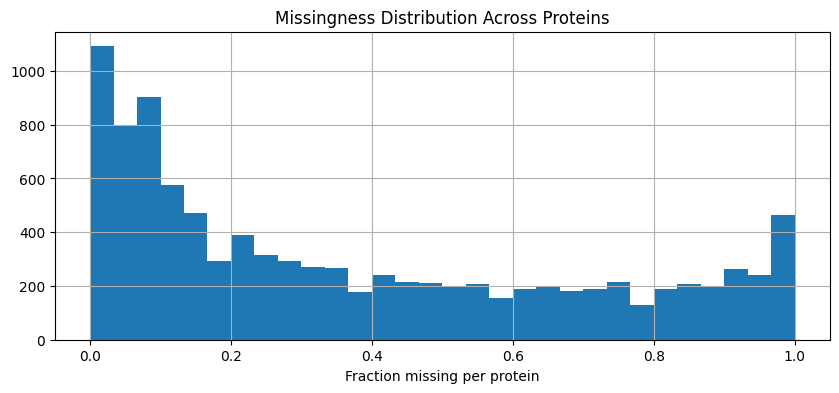

In [87]:
protein_missingness = tissue_data.iloc[:, 1:].isnull().mean(axis=1)
print("\nTop 5 proteins with most missing data:")
print(protein_missingness.sort_values(ascending=False).head(50))

# Visualize
plt.figure(figsize=(10,4))
protein_missingness.hist(bins=30)
plt.title("Missingness Distribution Across Proteins")
plt.xlabel("Fraction missing per protein")
plt.show()

In [88]:
protein_missingness = tissue_data.iloc[:, 3:].isnull().mean(axis=1) * 100

missingness_df = pd.DataFrame({
    'protein': tissue_data.iloc[:, 3],  
    'missingness_percentage': protein_missingness
})

missingness_df.to_csv('tissue_protein_missingness.csv', index=False)

print(missingness_df.head())

     protein  missingness_percentage
0  10.121942               19.277108
1  10.810051                6.024096
2   8.357053                7.228916
3   7.382471               34.939759
4   8.578271                0.000000


### Patient-Level Missingness


Top 5 patients with most missing data:
S081    0.932860
S091    0.838885
S095    0.836726
S008    0.834567
S080    0.826650
dtype: float64


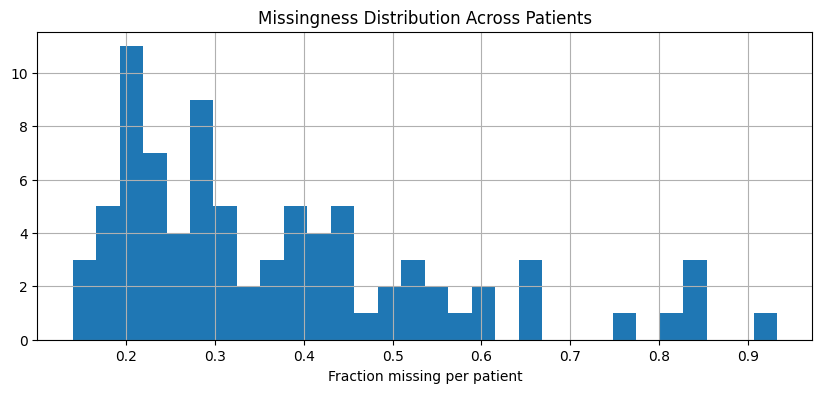

In [89]:
patient_missingness = tissue_data.iloc[:, 3:].isnull().mean(axis=0)
print("\nTop 5 patients with most missing data:")
print(patient_missingness.sort_values(ascending=False).head())

plt.figure(figsize=(10,4))
patient_missingness.hist(bins=30)
plt.title("Missingness Distribution Across Patients")
plt.xlabel("Fraction missing per patient")
plt.show()

In [41]:
patient_missingness = tissue_data.iloc[:, 1:].isnull().mean(axis=0) * 100

missingness_sample_df = pd.DataFrame({
    'sample': tissue_data.columns[1:],
    'missingness_percentage': patient_missingness
})

missingness_sample_df.to_csv('tissue_sample_missingness.csv', index=False)

print("\nTop 10 samples with most missing data:")
print(missingness_sample_df.sort_values(by='missingness_percentage', ascending=False).head(10))



Top 10 samples with most missing data:
     sample  missingness_percentage
S081   S081               93.286037
S091   S091               83.888546
S095   S095               83.672630
S008   S008               83.456714
S080   S080               82.665022
S006   S006               75.385564
S009   S009               66.625540
S087   S087               66.317088
S005   S005               66.306806
S084   S084               63.427925


In [49]:
plasma_data.columns

Index(['Unnamed: 0', 'Genes', 'S001', 'S002', 'S003', 'S004', 'S005', 'S060',
       'S006', 'S007', 'S008', 'S009', 'S062', 'S010', 'S011', 'S021', 'S012',
       'S013', 'S063', 'S014', 'S015', 'S023', 'S016', 'S017', 'S064', 'S018',
       'S019', 'S026', 'S020', 'S022', 'S024', 'S025', 'S030', 'S053', 'S032',
       'S033', 'S067', 'S034', 'S036', 'S068', 'S038', 'S039', 'S041', 'S069',
       'S043', 'S091', 'S045', 'S070', 'S046', 'S047', 'S092', 'S048', 'S049',
       'S071', 'S050', 'S093', 'S054', 'S055', 'S057', 'S094', 'S073', 'S074',
       'S080', 'S081', 'S096', 'S075', 'S085', 'S086', 'S088', 'S089', 'S072',
       'S082', 'S035', 'S078', 'S077', 'S095', 'S029', 'S037', 'S079', 'S061',
       'S066', 'S031', 'S052', 'S076', 'S083', 'S087', 'S090'],
      dtype='str')

#### Patient-level missingness (only matched data)

(9726, 86)

Top 10 patients with most missing data:
S081    0.932860
S091    0.838885
S095    0.836726
S008    0.834567
S080    0.826650
S006    0.753856
S009    0.666255
S087    0.663171
S005    0.663068
S093    0.606107
dtype: float64


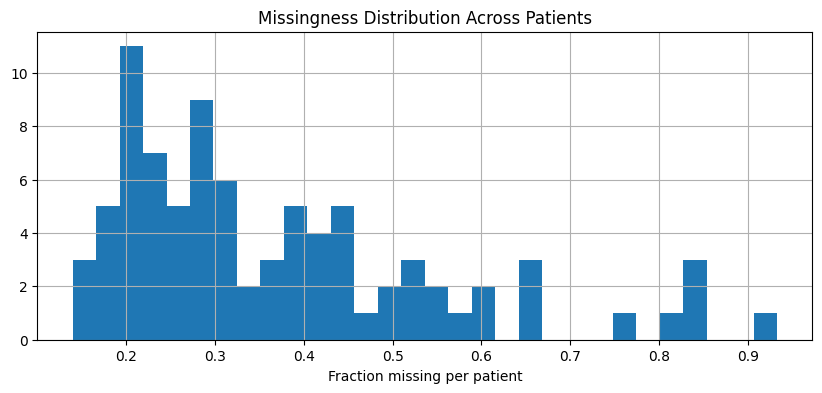

In [90]:
tissue_data_matched = tissue_data[matched_samples]
print(tissue_data_matched.shape)
patient_missingness_matched = tissue_data_matched.iloc[:, 1:].isnull().mean(axis=0)
print("\nTop 10 patients with most missing data:")
print(patient_missingness_matched.sort_values(ascending=False).head(10))

plt.figure(figsize=(10,4))
patient_missingness_matched.hist(bins=30)
plt.title("Missingness Distribution Across Patients")
plt.xlabel("Fraction missing per patient")
plt.show()

### Remove Samples with high missingness
Patients with high missingness can artifically inflate protein missingness

In [91]:
# Dynamic threshold - keep at least 70 patients (adjust as needed)
target_keep_patients = 75 
q = (tissue_data.shape[1] - 1/target_keep_patients)
print(q)
patient_threshold = np.percentile(patient_missingness_matched, q)

removed_patients = patient_missingness_matched[patient_missingness_matched > patient_threshold].index.tolist()
good_patients = patient_missingness_matched[patient_missingness_matched <= patient_threshold].index

filtered_by_patient = tissue_data[['Genes'] + good_patients.tolist()] 

print(f"\n=== PATIENT FILTERING ===")
print(f"Used adaptive threshold: {patient_threshold:.1%} missing")
print(f"Removed {len(removed_patients)} patients: {removed_patients}")
print(f"Retained {len(good_patients)} patients")

85.98666666666666

=== PATIENT FILTERING ===
Used adaptive threshold: 56.0% missing
Removed 12 patients: ['S005', 'S006', 'S008', 'S009', 'S016', 'S091', 'S093', 'S080', 'S081', 'S095', 'S037', 'S087']
Retained 73 patients


In [68]:
print(filtered_by_patient.shape)

(9726, 74)


Problem is, not the same samples are removed for plasma and tissue proteins

In [98]:
plasma_data = plasma_data[matched_samples]
print(plasma_data.shape)

(1896, 86)


In [104]:
target_keep_patients = 75 
q = (tissue_data.shape[1] - 1/target_keep_patients)
print(q)

patient_missingness_plasma = plasma_data.iloc[:, 1:].isnull().mean(axis=0)
print("\nPLASMA: Top 10 patients with most missing data:")
print(patient_missingness_plasma.sort_values(ascending=False).head(10))
print('TISSUE: Top 10 samples with most missing data:')
print(patient_missingness.sort_values(ascending=False).head(10))


patient_threshold = np.percentile(patient_missingness, q)
print(patient_threshold)
# 
removed_patients_tissue = patient_missingness[patient_missingness > patient_threshold].index.tolist()
good_patients_tissue = patient_missingness[patient_missingness<= patient_threshold].index

removed_patients_plasma = patient_missingness_plasma[patient_missingness_plasma > patient_threshold].index.tolist()
good_patients_plasma = patient_missingness_plasma[patient_missingness_plasma <= patient_threshold].index

# filtered_by_patient = tissue_data[['Genes'] + good_patients.tolist()] 
# 
print(f"\n=== PATIENT FILTERING ===")
print(f"Used adaptive threshold: {patient_threshold:.1%} missing")
print(f"TISSUE: Removed {len(removed_patients_tissue)} patients: {removed_patients_tissue}")
print(f"Retained {len(good_patients_tissue)} patients")
print(f'PLASMA: Removed {len(removed_patients_plasma)}: {removed_patients_plasma}')
print(f"Retained {len(good_patients_plasma)} patients")

85.98666666666666

PLASMA: Top 10 patients with most missing data:
S046    0.597046
S052    0.558544
S057    0.526899
S090    0.497890
S067    0.486814
S031    0.469409
S071    0.452004
S035    0.447257
S068    0.444093
S050    0.416667
dtype: float64
TISSUE: Top 10 samples with most missing data:
S081    0.932860
S091    0.838885
S095    0.836726
S008    0.834567
S080    0.826650
S006    0.753856
S009    0.666255
S087    0.663171
S005    0.663068
S093    0.606107
dtype: float64
0.5650791418191788

=== PATIENT FILTERING ===
Used adaptive threshold: 56.5% missing
TISSUE: Removed 12 patients: ['S005', 'S006', 'S008', 'S009', 'S016', 'S091', 'S093', 'S080', 'S081', 'S095', 'S037', 'S087']
Retained 71 patients
PLASMA: Removed 1: ['S046']
Retained 84 patients


In [92]:
protein_missingness = filtered_by_patient.iloc[:, 1:].isnull().mean(axis=1)

MIN_DATA_PRESENCE = 0.80
protein_threshold = 1 - MIN_DATA_PRESENCE

good_proteins = protein_missingness[protein_missingness <= protein_threshold].index
removed_proteins = protein_missingness[protein_missingness > protein_threshold].index.tolist()

final_expression_PTPR = filtered_by_patient.loc[good_proteins]

print(f"\n=== PROTEIN FILTERING ===")
print(f"Threshold: ≥{MIN_DATA_PRESENCE:.0%} data presence (≤{protein_threshold:.0%} missing)")
print(f"Removed {len(removed_proteins)} proteins with low data presence")
print(f"Retained {len(good_proteins)} proteins")

#final_expression_PTPR.to_csv('final_expression_PTPR.csv', index=False)



=== PROTEIN FILTERING ===
Threshold: ≥80% data presence (≤20% missing)
Removed 4609 proteins with low data presence
Retained 5117 proteins


In [93]:
final_expression_PTPR.shape


(5117, 74)

In [75]:
protein_missingness = tissue_data[matched_samples].iloc[:, 1:].isnull().mean(axis=1)

MIN_DATA_PRESENCE = 0.80
protein_threshold = 1 - MIN_DATA_PRESENCE

good_proteins = protein_missingness[protein_missingness <= protein_threshold].index
removed_proteins = protein_missingness[protein_missingness > protein_threshold].index.tolist()

final = filtered_by_patient.loc[good_proteins]

print(f"\n=== PROTEIN FILTERING ===")
print(f"Threshold: ≥{MIN_DATA_PRESENCE:.0%} data presence (≤{protein_threshold:.0%} missing)")
print(f"Removed {len(removed_proteins)} proteins with low data presence")
print(f"Retained {len(good_proteins)} proteins")
#final_expression_PTPR.to_csv('final_expression_PTPR.csv', index=False)



=== PROTEIN FILTERING ===
Threshold: ≥80% data presence (≤20% missing)
Removed 5596 proteins with low data presence
Retained 4130 proteins


In [76]:
final.shape

(4130, 74)


Top 10 patients with most missing data:
S032    0.226109
S067    0.209693
S090    0.185265
S079    0.178816
S033    0.168263
S053    0.159859
S078    0.159273
S094    0.122533
S039    0.112761
S074    0.110025
dtype: float64


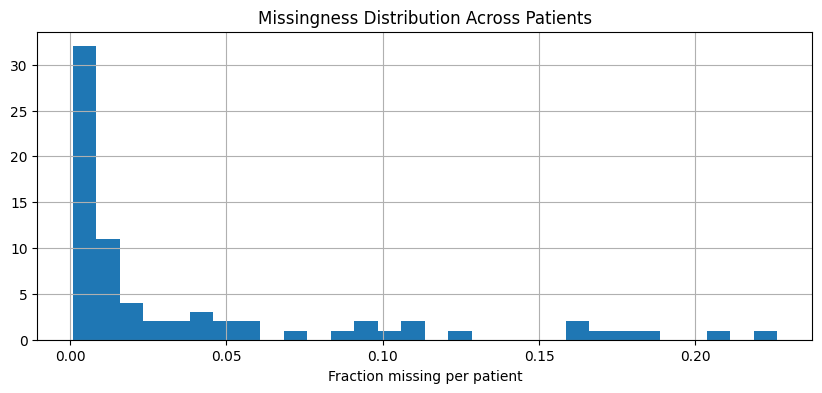

In [94]:

patient_missingness_matched = final_expression_PTPR.iloc[:, 1:].isnull().mean(axis=0)
print("\nTop 10 patients with most missing data:")
print(patient_missingness_matched.sort_values(ascending=False).head(10))

plt.figure(figsize=(10,4))
patient_missingness_matched.hist(bins=30)
plt.title("Missingness Distribution Across Patients")
plt.xlabel("Fraction missing per patient")
plt.show()


Top 5 proteins with most missing data:
9583    0.191781
9459    0.191781
9170    0.191781
9167    0.191781
9040    0.191781
8740    0.191781
8678    0.191781
8667    0.191781
8536    0.191781
8498    0.191781
8487    0.191781
8413    0.191781
8310    0.191781
8280    0.191781
8277    0.191781
8225    0.191781
8147    0.191781
7877    0.191781
7742    0.191781
7721    0.191781
7612    0.191781
7419    0.191781
7248    0.191781
7227    0.191781
7131    0.191781
7097    0.191781
7007    0.191781
6900    0.191781
6834    0.191781
6828    0.191781
6821    0.191781
6807    0.191781
6654    0.191781
6599    0.191781
6538    0.191781
6475    0.191781
6329    0.191781
6317    0.191781
6311    0.191781
6271    0.191781
6209    0.191781
5974    0.191781
5936    0.191781
5932    0.191781
5921    0.191781
5828    0.191781
5794    0.191781
5717    0.191781
5659    0.191781
5626    0.191781
dtype: float64


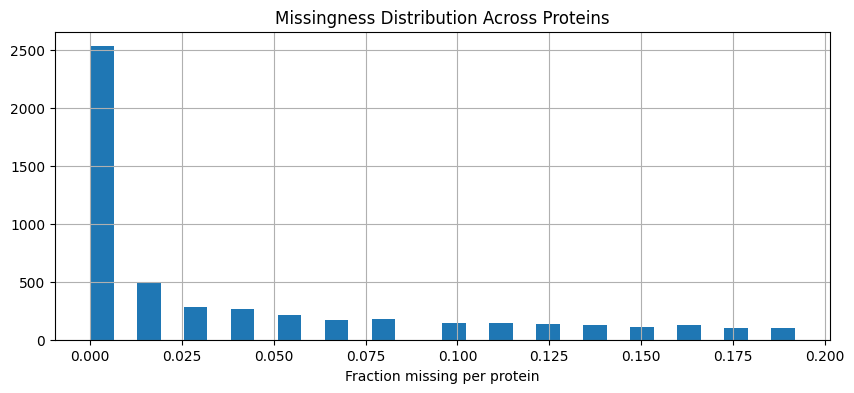

In [95]:
protein_missingness = final_expression_PTPR.iloc[:, 1:].isnull().mean(axis=1)
print("\nTop 5 proteins with most missing data:")
print(protein_missingness.sort_values(ascending=False).head(50))

# Visualize
plt.figure(figsize=(10,4))
protein_missingness.hist(bins=30)
plt.title("Missingness Distribution Across Proteins")
plt.xlabel("Fraction missing per protein")
plt.show()

In [96]:
final_expression_PTPR.columns

Index(['Genes', 'S001', 'S002', 'S003', 'S004', 'S060', 'S007', 'S062', 'S010',
       'S011', 'S021', 'S012', 'S013', 'S063', 'S014', 'S015', 'S023', 'S017',
       'S064', 'S018', 'S019', 'S026', 'S020', 'S022', 'S024', 'S025', 'S030',
       'S053', 'S032', 'S033', 'S067', 'S034', 'S036', 'S068', 'S038', 'S039',
       'S041', 'S069', 'S043', 'S045', 'S070', 'S046', 'S047', 'S092', 'S048',
       'S049', 'S071', 'S050', 'S054', 'S055', 'S057', 'S094', 'S073', 'S074',
       'S096', 'S075', 'S085', 'S086', 'S088', 'S089', 'S072', 'S082', 'S035',
       'S078', 'S077', 'S029', 'S079', 'S061', 'S066', 'S031', 'S052', 'S076',
       'S083', 'S090'],
      dtype='str')